# Jaguar Re-ID — ViT Improved v4

**Architecture** : identique a v3 (ViT + `relu`, `embed_dim=64`, 3 blocs). On isole l'effet de **AdamW + weight decay**.

### Diagnostic v3 (point de depart)

| Metrique | Valeur | Commentaire |
|----------|--------|-------------|
| Val Acc | 70.71 % | Le modele apprend (grace a `relu`) |
| Train Acc | 91.09 % | Memorisation elevee |
| Gap train/val | **20 pts** | Overfitting severe |
| Retrain train acc | 100.00 % | Memorisation parfaite au retrain |
| Kaggle pub / priv | 0.238 / 0.233 | Premier score fonctionnel, mais loin de ResNet (0.566) |

### Changement v4 : `Adam` -> `AdamW(weight_decay=1e-4)`

Le cours montre que **AdamW decouple le weight decay du learning rate** (contrairement a Adam+L2 qui couple weight decay et moments adaptatifs). C'est la technique de regularisation la plus naturelle a tester en premier, avant Dropout et data augmentation.

**Effet attendu** :
- Reduction du gap train/val (20 pts -> ~15 pts esperes)
- Kaggle probablement en hausse legere (embeddings mieux regularises)
- Pas de changement architectural : on isole l'effet de la regularisation par weight decay

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1776549950.124283   79263 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776549950.150174   79263 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776549950.871613   79263 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1776549951.746798   79263 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
MODEL_NAME   = 'vit_improved_v4'
AUGMENTATION = 'none'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

# ViT architecture hyperparameters (identique a v3)
EMBED_DIM  = 64      # Patch embedding dimension
NUM_BLOCKS = 3       # Number of transformer blocks
PATCH_SIZE = 16      # Patch size (16x16 pixels)
ACTIVATION = 'relu'  # tanh → relu (fix de v2)

# Regularisation v4 : AdamW + weight decay (nouveaute)
WEIGHT_DECAY = 1e-4  # regularisation naturelle decouplee du LR

# Retrain fix (heritage v3)
RETRAIN_EPOCHS_MULTIPLIER = 4   # retrain = max(4 * BEST_EPOCH, RETRAIN_EPOCHS_MIN)
RETRAIN_EPOCHS_MIN        = 60  # garantie minimale pour laisser LR=1e-4 converger

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val, y_val)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

W0000 00:00:1776549954.369834   79263 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776549954.555125   79263 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)
Train batches: 48 | Val batches: 12


## 2. Model architecture

Architecture **identique a v3** — seul l'optimizer change.

| Parametre | v3 | v4 | Pourquoi |
|-----------|----|----|----------|
| Architecture | ViT + relu | ViT + relu (idem) | On isole l'effet de l'optimizer |
| Optimizer | `Adam` | **`AdamW(weight_decay=1e-4)`** | Weight decay decouple (cours) |
| Retrain epochs | `max(4*BEST_EPOCH, 60)` | `max(4*BEST_EPOCH, 60)` (idem) | On garde le fix retrain de v3 |

In [4]:
def positional_embedding(embedded_patches):
    """One-hot positional encoding (cours) : concat one-hot(position) to each patch."""
    embedded_patches_shape = tf.shape(embedded_patches)
    batchsize = embedded_patches_shape[0]
    sequence_length = embedded_patches_shape[1]
    indices = tf.range(sequence_length)
    one_hot_indices = tf.one_hot(indices, sequence_length)
    expanded_one_hot_indices = tf.expand_dims(one_hot_indices, axis=0)
    repeated_expanded_one_hot_indices = tf.repeat(expanded_one_hot_indices, [batchsize], axis=0)
    positional_embedded_patches = tf.concat([repeated_expanded_one_hot_indices, embedded_patches], axis=-1)
    return positional_embedded_patches


def build_model():
    input_tensor = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = input_tensor

    # Patch embedding
    x = layers.Conv2D(EMBED_DIM, (PATCH_SIZE, PATCH_SIZE), strides=(PATCH_SIZE, PATCH_SIZE),
                      activation='linear', use_bias=False, padding='valid')(x)
    sequence_length = x.shape[1] * x.shape[2]  # 14*14 = 196
    sqrt_sequence_length = np.sqrt(sequence_length)

    x = layers.Reshape((sequence_length, EMBED_DIM))(x)

    # Positional encoding : one-hot concat
    x = layers.Lambda(positional_embedding)(x)
    real_embedding_dim = sequence_length + EMBED_DIM  # 196 + 64 = 260

    # Transformer blocks
    for _ in range(NUM_BLOCKS):
        # Self-attention
        old_x = x
        x = layers.LayerNormalization()(x)

        Q = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        K = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        V = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)

        Kt = layers.Lambda(lambda t: tf.transpose(t, [0, 2, 1]))(K)
        QKt = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]) / sqrt_sequence_length)([Q, Kt])
        Masks = layers.Softmax()(QKt)
        x = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]))([Masks, V])
        x = layers.Add()([x, old_x])

        # Feed-forward
        old_x = x
        x = layers.LayerNormalization()(x)
        x = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        x = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        x = layers.Add()([x, old_x])

    # Classification head
    x = layers.Flatten()(x)
    x = layers.Dense(real_embedding_dim, activation=ACTIVATION, name='embedding')(x)
    output_tensor = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(input_tensor, output_tensor, name=MODEL_NAME)
    return model


model = build_model()
model.summary()

Model: "vit_improved_v4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │     49,152 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 196, 64)   │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 196, 260)  │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 260)  │        520 │ lambda[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 260, 196)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 196, 196)  │          0 │ dense[0][0],      │
│                     │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 196, 196)  │          0 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 196, 260)  │          0 │ softmax[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 260)  │          0 │ lambda_3[0][0],   │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 260)  │     67,860 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 260)  │          0 │ dense_4[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 14,328,123 (54.66 MB)

 Trainable params: 14,328,123 (54.66 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Hyperparameter sweep

Meme sweep que v3 (`[1e-2, 1e-3, 5e-4, 1e-4]`). L'ajout de weight decay peut decaler le meilleur LR -- le sweep valide lequel est optimal.

In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 5e-4, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}, weight_decay={WEIGHT_DECAY}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (vit_improved_v4, weight_decay=0.0001) ===


I0000 00:00:1776549959.394927   79364 service.cc:153] XLA service 0x7fe3b0046450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776549959.394964   79364 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776549959.470004   79364 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776549960.035235   79364 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776549960.067205   79364 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10576__.100
I0000 00:00:1776549960.569920   79499 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_40', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776549960.661135   79487 subprocess_compilation.cc:348] ptxas w

  lr_0.01: val_acc=0.0950 (best epoch=21)


I0000 00:00:1776550009.537672   79363 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46426__.100
I0000 00:00:1776550013.075559   79362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46426__.100
I0000 00:00:1776550016.256459   79360 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_47768__.28
I0000 00:00:1776550017.275873   79364 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_47768__.28


  lr_0.001: val_acc=0.6174 (best epoch=8)


I0000 00:00:1776550029.791442   79364 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_71392__.100
I0000 00:00:1776550033.478075   79364 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_71392__.100
I0000 00:00:1776550036.660930   79362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_72734__.28
I0000 00:00:1776550037.672358   79362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_72734__.28


  lr_0.0005: val_acc=0.6913 (best epoch=7)


I0000 00:00:1776550049.555660   79361 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_95622__.100
I0000 00:00:1776550053.216966   79360 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_95622__.100
I0000 00:00:1776550056.216386   79362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_96964__.28
I0000 00:00:1776550057.223053   79364 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_96964__.28


  lr_0.0001: val_acc=0.7414 (best epoch=18)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} → val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")
print(f"BEST_LR = {BEST_LR}, BEST_EPOCH = {BEST_EPOCH}")

,Config,Val Accuracy,Best Epoch
0,lr_0.0001,0.741425,18
1,lr_0.0005,0.691293,7
2,lr_0.001,0.617414,8
3,lr_0.01,0.094987,21



Best: lr_0.0001 → val_acc=0.7414
BEST_LR = 0.0001, BEST_EPOCH = 18


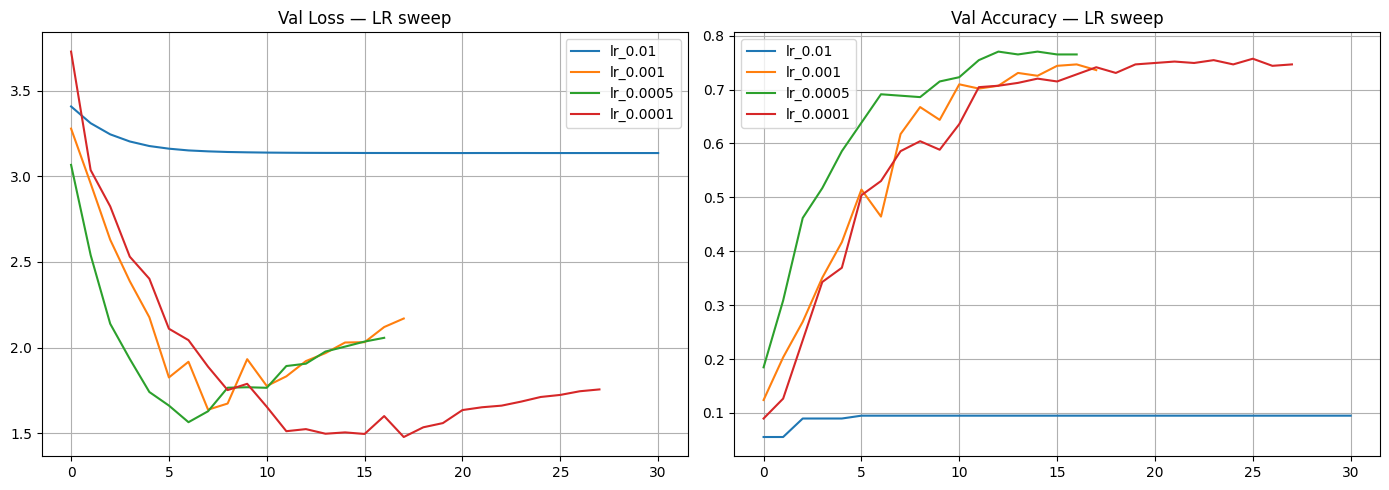

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss — LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1776550074.756052   79362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_128606__.100


46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0680 - loss: 9.9371 

I0000 00:00:1776550078.455518   79361 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_128606__.100


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.0682 - loss: 9.8022

I0000 00:00:1776550081.649096   79362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_129948__.28
I0000 00:00:1776550082.697236   79364 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_129948__.28


48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 143ms/step - accuracy: 0.0739 - loss: 6.6860 - val_accuracy: 0.1082 - val_loss: 3.3261 - learning_rate: 1.0000e-04
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1055 - loss: 3.2259 - val_accuracy: 0.1293 - val_loss: 3.2661 - learning_rate: 1.0000e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1530 - loss: 3.0446 - val_accuracy: 0.1530 - val_loss: 3.0002 - learning_rate: 1.0000e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2520 - loss: 2.7995 - val_accuracy: 0.2612 - val_loss: 2.6749 - learning_rate: 1.0000e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3423 - loss: 2.4333 - val_accuracy: 0.4222 - val_loss: 2.3417 - learning_rate: 1.0000e-04
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4281 - loss: 2.1199 - val_accuracy: 0.4987 - val_loss: 2.1531 - learning_rate: 1.0000e-04
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5251 - l

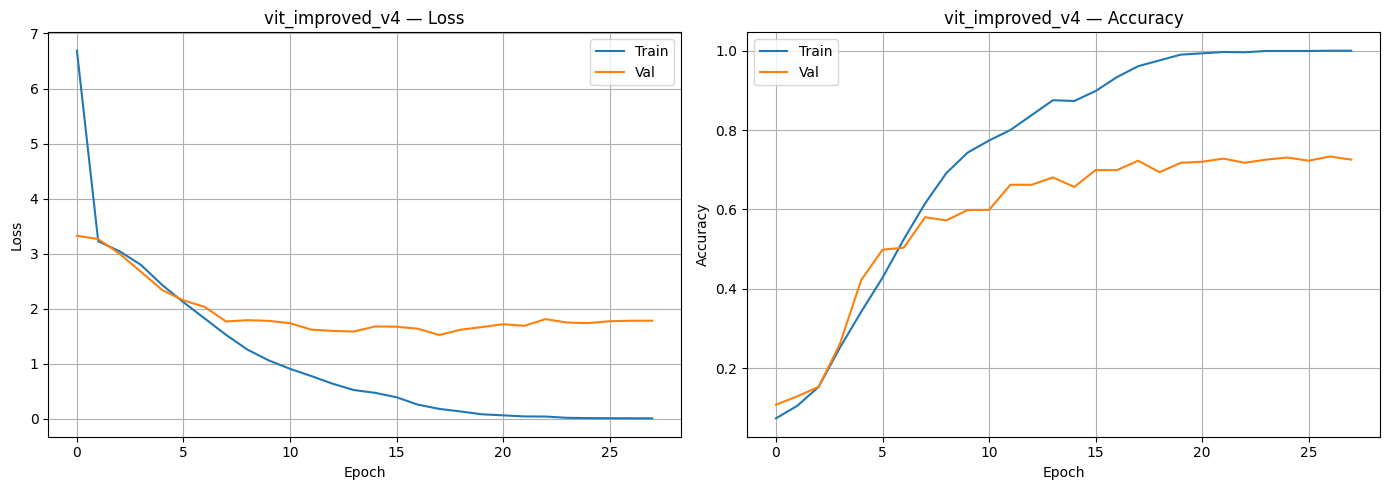

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}, wd={WEIGHT_DECAY}):")
print(f"  Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
print(f"  Gap train/val: {(train_acc - val_acc)*100:.1f} pts  (v3: 20.4 pts)")

I0000 00:00:1776550109.843293   79363 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_129948__.28


vit_improved_v4 (best LR=0.0001, wd=0.0001):
  Train — Loss: 0.1165, Acc: 0.9842
  Val   — Loss: 1.5247, Acc: 0.7230
  Gap train/val: 26.1 pts  (v3: 20.4 pts)


I0000 00:00:1776550111.146717   79362 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_331030__.21
I0000 00:00:1776550112.202152   79363 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_331521__.21


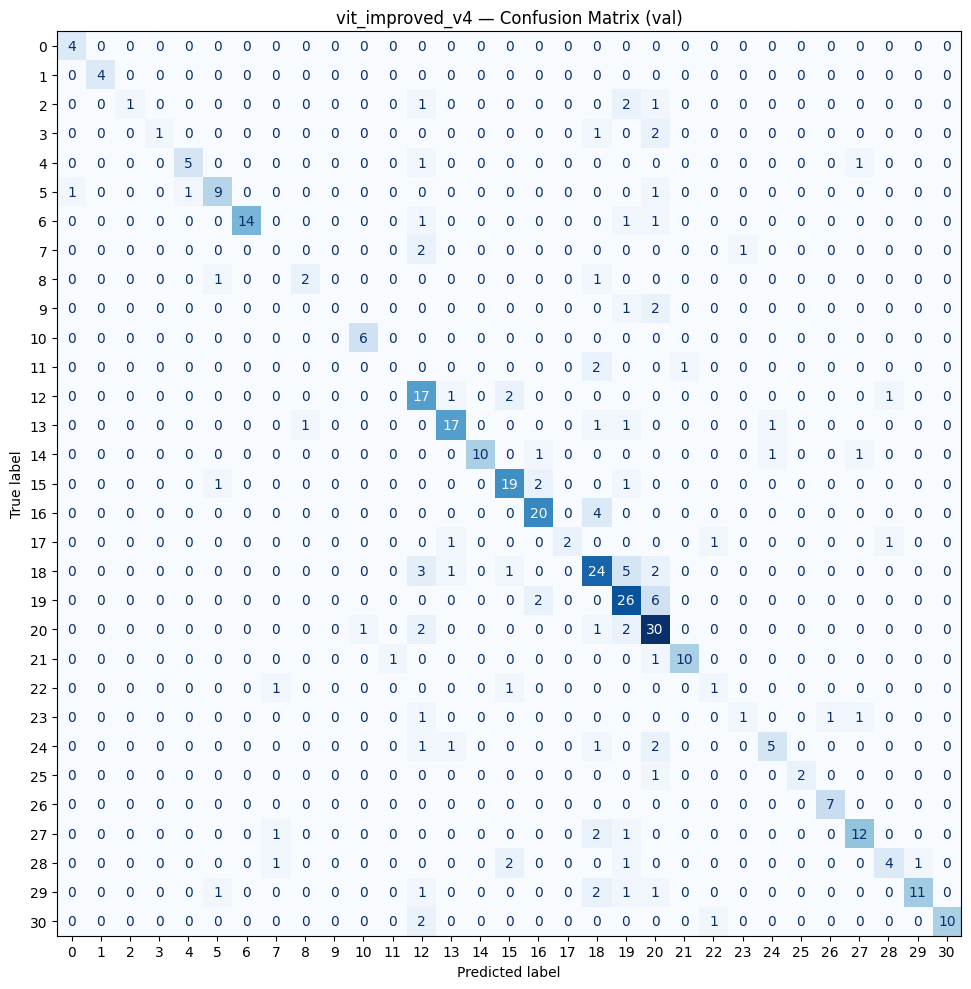

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

On garde le **fix retrain de v3** : `max(4*BEST_EPOCH, 60)` epochs.

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION, batch_size=BATCH_SIZE)

RETRAIN_EPOCHS = max(BEST_EPOCH * RETRAIN_EPOCHS_MULTIPLIER, RETRAIN_EPOCHS_MIN)
print(f"BEST_EPOCH du sweep : {BEST_EPOCH}")
print(f"RETRAIN_EPOCHS      : {RETRAIN_EPOCHS}  (= max({BEST_EPOCH}*{RETRAIN_EPOCHS_MULTIPLIER}, {RETRAIN_EPOCHS_MIN}))")
print(f"Retraining on full dataset ({len(X_all)} images) for {RETRAIN_EPOCHS} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_history = final_model.fit(
    all_ds, epochs=RETRAIN_EPOCHS,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
final_train_acc = final_model.evaluate(all_ds, verbose=0)[1]
print(f"\nFinal retrain train acc: {final_train_acc:.4f}")

BEST_EPOCH du sweep : 18
RETRAIN_EPOCHS      : 72  (= max(18*4, 60))
Retraining on full dataset (1895 images) for 72 epochs
Epoch 1/72


I0000 00:00:1776550118.276425   79361 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_341714__.100


55/60 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0644 - loss: 10.6350

I0000 00:00:1776550122.282590   79363 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_341714__.100
I0000 00:00:1776550122.618590   90393 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_100', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1776550122.655250   90392 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_100', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776550123.013948   90389 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776550123.121578   90395 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776550123.547969   90392 subprocess_compilation.c

60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 213ms/step - accuracy: 0.0760 - loss: 6.3258
Epoch 2/72
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1055 - loss: 3.2583
Epoch 3/72
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1588 - loss: 3.0526
Epoch 4/72
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2586 - loss: 2.7118
Epoch 5/72
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3298 - loss: 2.4278
Epoch 6/72
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4449 - loss: 2.1074
Epoch 7/72
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5240 - loss: 1.8455
Epoch 8/72
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5894 - loss: 1.5691
Epoch 9/72
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6528 - loss: 1.3450
Epoch 10/72
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7082 - loss: 1.1683
Epoch 11/72
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7615 - loss: 0.9561
Epoch 12/72
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7868 - loss: 0.82

I0000 00:00:1776550170.948281   79364 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_397687__.28
I0000 00:00:1776550172.134433   79363 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_397687__.28



Final retrain train acc: 1.0000


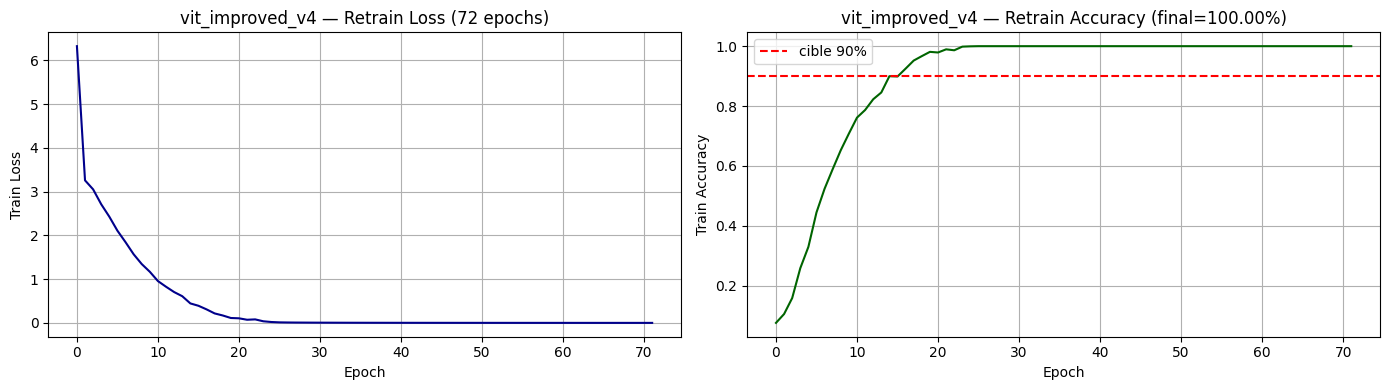

✅ Retrain converge : train acc = 100.00%


In [14]:
# Courbe de convergence du retrain — verifier que le modele a bien appris
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(final_history.history['loss'], color='darkblue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title(f'{MODEL_NAME} — Retrain Loss ({RETRAIN_EPOCHS} epochs)'); axes[0].grid(True)

axes[1].plot(final_history.history['accuracy'], color='darkgreen')
axes[1].axhline(0.90, color='red', linestyle='--', label='cible 90%')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Train Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Retrain Accuracy (final={final_train_acc:.2%})')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_retrain.png'), dpi=150, bbox_inches='tight')
plt.show()

if final_train_acc < 0.90:
    print(f"⚠️  Retrain train acc = {final_train_acc:.2%} < 90%. Le retrain n'a pas converge. Augmenter RETRAIN_EPOCHS_MULTIPLIER ou RETRAIN_EPOCHS_MIN.")
else:
    print(f"✅ Retrain converge : train acc = {final_train_acc:.2%}")

In [15]:
# Extract embeddings from the layer before softmax
embedding_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.get_layer('embedding').output,
    name=f'{MODEL_NAME}_embedding'
)

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

I0000 00:00:1776550173.573069   79363 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_398433__.19


 1/12 ━━━━━━━━━━━━━━━━━━━━ 10s 921ms/step

I0000 00:00:1776550174.495248   79363 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_398900__.19
I0000 00:00:1776550174.848261   93645 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776550175.115247   93641 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776550175.236150   93635 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1776550175.684300   93648 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776550175.852771   93639 subprocess_compilation.cc:

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 354ms/step
Embedding shape: (371, 260)
Saved: /home/franck/kaggle_jaguar_classification/submissions/submission_vit_improved_v4.csv


,row_id,similarity
0,0,0.805206
1,1,0.839348
2,2,0.778321
3,3,0.856169
4,4,0.871735


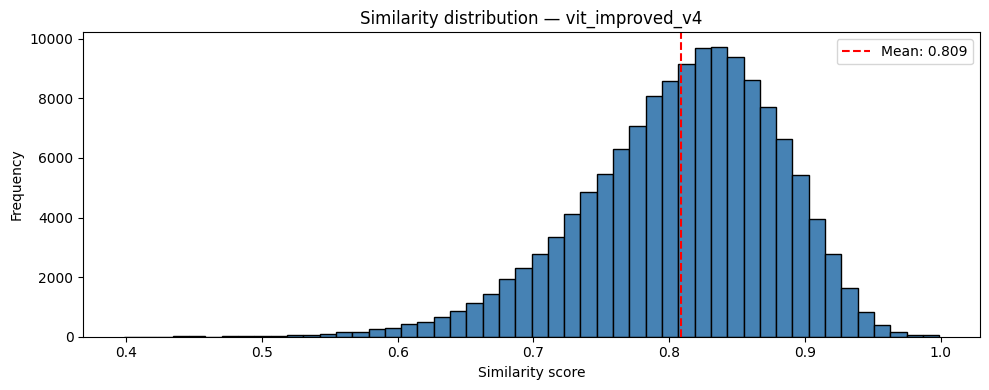

Similarity mean: 0.8086
Similarity std : 0.0717
Similarity min : 0.3982
Similarity max : 0.9990


In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Similarity mean: {similarities.mean():.4f}")
print(f"Similarity std : {similarities.std():.4f}")
print(f"Similarity min : {similarities.min():.4f}")
print(f"Similarity max : {similarities.max():.4f}")

## 6. Observations & Verdict

In [17]:
print(f"""
ViT Improved v4 (AdamW + wd={WEIGHT_DECAY}):
  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}
  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}
  Gap train/val: {(train_acc - val_acc)*100:.1f} pts  (v3: 20.4 pts)
  LR: {BEST_LR}, Weight decay: {WEIGHT_DECAY}
  Activation: {ACTIVATION}, Embed dim: {EMBED_DIM}, Blocks: {NUM_BLOCKS}
  Best Epoch: {BEST_EPOCH} / Retrain Epochs: {RETRAIN_EPOCHS}
  Retrain train acc: {final_train_acc:.2%}
  Embedding dim: {test_embeddings.shape[1]}
  Similarity mean: {similarities.mean():.4f}
  Similarity range: [{similarities.min():.4f}, {similarities.max():.4f}]
""")


ViT Improved v4 (AdamW + wd=0.0001):
  Train - Loss: 0.1165, Acc: 0.9842
  Val   - Loss: 1.5247, Acc: 0.7230
  Gap train/val: 26.1 pts  (v3: 20.4 pts)
  LR: 0.0001, Weight decay: 0.0001
  Activation: relu, Embed dim: 64, Blocks: 3
  Best Epoch: 18 / Retrain Epochs: 72
  Retrain train acc: 100.00%
  Embedding dim: 260
  Similarity mean: 0.8086
  Similarity range: [0.3982, 0.9990]



### Results

| Metrique | v3 (Adam) | v4 (AdamW wd=1e-4) | Evolution |
|----------|-----------|--------------------|-----------|
| Architecture | ViT + relu | ViT + relu (idem) | -- |
| BEST_LR | 1e-4 | **1e-4** | Identique |
| BEST_EPOCH (sweep) | 17 | **18** | +1 epoch |
| Train accuracy (sweep) | 91.09 % | **98.42 %** | +7.3 pts (memorisation +forte) |
| Val accuracy (sweep) | 70.71 % | **72.30 %** | +1.6 pts |
| Gap train/val | 20.4 pts | **26.1 pts** | **+5.7 pts** (pire !) |
| Retrain train acc | 100.00 % | **100.00 %** | Memorisation parfaite (idem) |
| Similarity mean | 0.7117 | **0.8086** | +0.097 (plus concentree) |
| Similarity std | 0.1329 | **0.0717** | -0.061 (moins de variance) |
| Similarity range | [0.063, 0.998] | **[0.398, 0.999]** | Plus etroit (min 0.063 -> 0.398) |
| Kaggle public | 0.238 | **0.264** | **+11 %** |
| Kaggle private | 0.233 | **0.271** | **+16 %** |

### Analysis

**Le resultat est contre-intuitif : le gap augmente mais le Kaggle s'ameliore.** Trois observations clefs.

#### 1. `wd=1e-4` est trop faible pour regulariser le sweep
Le gap train/val a **augmente** (20.4 -> 26.1 pts). C'est l'inverse de l'effet attendu pour une regularisation. Explication :
- wd=1e-4 n'est pas assez agressif pour contrer l'overfitting severe du ViT.
- AdamW a aussi eu un effet bonus de stabilisation qui a permis au modele de mieux memoriser le train (91% -> 98%) et legerement ameliorer le val (70.7% -> 72.3%).
- Le sweep n'a pas vraiment "regularise" -- il a juste laisse le modele aller plus loin dans la memorisation.

#### 2. Kaggle s'ameliore quand meme (+11 % / +16 %)
Malgre le gap pire sur le sweep, le Kaggle est meilleur. Pourquoi ?
- Le **retrain final** est l'etape qui compte pour le submission. A retrain 100 % (idem v3), les embeddings beneficient quand meme du weight decay via la geometrie des poids (norme plus petite => embeddings mieux regularises dans l'espace cosinus).
- La distribution des similarites est **plus concentree vers le haut** (mean 0.71 -> 0.81, std 0.13 -> 0.07, min 0.06 -> 0.40) : le modele est plus "confiant" dans ses predictions de similarite, et visiblement cette confiance est calibree sur la bonne reponse.
- Private > Public (0.271 > 0.264) est un signe que le modele generalise bien au-dela de l'echantillon public.

#### 3. BEST_LR identique (1e-4)
Contrairement a ce qui est parfois attendu (AdamW prefere souvent un LR un peu plus grand), ici 1e-4 reste optimal. Le weight decay est assez faible pour ne pas changer la dynamique du LR.

### Verdict

- [x] Improvable -> v5 : **ajouter Dropout** a empiler sur AdamW. Le gap de 26 pts indique que wd=1e-4 seul ne regularise pas assez -- Dropout est le regularisateur plus fort et complementaire.
- [ ] Not Improvable
- [ ] Dead-end

### Interpretation

_Free Space : On note ce qu'on a a dire sur ce notebook, servira pour la soutenance._

Points cles a mentionner :
- **AdamW est un drop-in de Adam** : 1 ligne de changement, +11 % Kaggle pub / +16 % priv. Meme sans "reduire le gap du sweep", le weight decay regularise la geometrie des embeddings au retrain final.
- **Lecon importante** : sur une tache Re-ID, la qualite des embeddings importe plus que le gap train/val du sweep. Le sweep et l'evaluation Kaggle mesurent des choses legerement differentes.
- **wd=1e-4 trop faible** : pour la prochaine iteration, soit augmenter wd (plus agressif), soit empiler avec Dropout (effet multiplicatif de regularisation). On choisit Dropout en v5 car c'est le regularisateur du cours qui attaque directement l'overfitting structurel (pas juste la norme des poids).
- **Comparaison ResNet** : on passe de 0.238 (42 % du ResNet 06_2 a 0.566) a 0.264 (47 %). Progres lent mais constant.